# Partial orbit

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from exogaia.data import GaiaAstrometry
from exogaia.leastsq import LeastSquares
from exogaia.results import SamplingResults
from exogaia.samplers import NestedSampler

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


## Simulate Gaia epoch astrometry

The ``GaiaAstrometry`` class is used to store and analyze Gaia epoch astrometry. The stellar parameters can either be specified manually or retrieved from Gaia DR3.

In this example, we simulate a planetary system by manually providing the stellar parameters. We adopt a planet with a relative semi-major axis of 4 au, corresponding to an orbital period that is substantially longer than the Gaia DR4 observing baseline.

We then investigate how well the star's position, and therefore the planet's position, can be constrained at a given epoch (1 July 2027).

In [3]:
primary_mass = (1.0, 0.1)  # (Msun)
mass_2 = 0.01  # (Msun)
flux_ratio = 0.0  # non-luminous companion

In [4]:
model_param = {
    "ra_ref": 50.0,
    "dec_ref": 20.0,
    "ra_offset": 0.0,
    "dec_offset": 0.0,
    "parallax": 20.0,
    "pm_ra": 30.0,
    "pm_dec": -30.0,
    "g_mag": 7.0,
    "ecc": 0.2,
    "tau": 0.25,
    "inc": np.radians(60.0),
    "aop": np.radians(30.0),
    "pan": np.radians(100.0),
    "sma": 4.0,
}

In [5]:
epoch_astrom = GaiaAstrometry(
    primary_mass=primary_mass, gaia_release="DR4", verbose=True
)


Gaia astrometry

Gaia release: DR4
Reference epoch: J2017.500

Primary mass (Msun): 1.00 +/- 0.10


In [6]:
model_param = epoch_astrom.simulate_data(
    model_param=model_param,
    mass_2=mass_2,
    flux_ratio=flux_ratio,
    occ_rate=None,
    sigma_per_ccd=None,
    csv_out=None,
    seed=1,
    reject_fraction=False,
)


-------------
Simulate data
-------------

System type: binary

Primary mass (Msun): 1.00 +/- 0.10

AL scan uncertainty (per CCD) = 159.98 uas
AL scan uncertainty (per transit) = 56.56 uas

Additional parameters:
   - Primary mass (Msun) = 1.00
   - Companion mass (Msun) = 1.00e-02
   - Mass ratio = 1.00e-02
   - Flux ratio = 0.00e+00
   - Relative semi-major axis (au) = 4.00

Star model

Epoch astrometry: GaiaAstrometry

-----------------------
Calculate stellar track
-----------------------

Stellar parameters:
   - RA offset (mas) = 0.000
   - Dec offset (mas) = 0.000
   - Parallax (mas) = 20.000
   - Proper motion in RA (mas/yr) = 30.000
   - Proper motion in Dec (mas/yr) = -30.000

Kepler model

Epoch astrometry: GaiaAstrometry

---------------------
Calculate orbit model
---------------------

Orbit parameters:
   - Period (days) = 2907.499
   - Eccentricity = 0.200
   - Relative time of periastron = 0.250
   - Semi-major axis (mas) = 80.000
   - Inclination (deg) = 60.000
   - 

## Orbit fit with nested sampling

In [7]:
sampler = NestedSampler(
    epoch_astrometry=epoch_astrom, least_squares=None, restrict_node=True
)


Nested sampler

Primary mass (Msun) = 1.00 +/- 0.10
Number of parameters: 12

Priors:
   - ra_offset -> Uniform: [-100.00, 100.00]
   - dec_offset -> Uniform: [-100.00, 100.00]
   - parallax -> Uniform: [0.00, 100.00]
   - pmra -> Uniform: [-200.00, 200.00]
   - pmdec -> Uniform: [-200.00, 200.00]
   - per -> LogUniform: [1.00e+01, 5.00e+03]
   - ecc -> Uniform: [0.00, 1.00]
   - tau -> Uniform: [0.00, 1.00]
   - sma -> LogUniform: [1.00e-03, 1.00e+02]
   - inc -> Sin: arccos(1 - 2u)
   - aop -> Uniform: [0.00, 6.28]
   - pan -> Uniform: [0.00, 3.14]


In [8]:
sampler.run_dynesty(
    pickle_file='exogaia.pkl',
    n_live_points=200,
    dynamic=True,
    sample_method='auto',
    bound='multi',
    n_pool=None,
    mpi_pool=False,
    evidence_tolerance=1.0,
)


-----------
Run Dynesty
-----------

Priors:
   - ra_offset = Uniform: [-100.00, 100.00]
   - dec_offset = Uniform: [-100.00, 100.00]
   - parallax = Uniform: [0.00, 100.00]
   - pmra = Uniform: [-200.00, 200.00]
   - pmdec = Uniform: [-200.00, 200.00]
   - per = LogUniform: [1.00e+01, 5.00e+03]
   - ecc = Uniform: [0.00, 1.00]
   - tau = Uniform: [0.00, 1.00]
   - sma = LogUniform: [1.00e-03, 1.00e+02]
   - inc = Sin: arccos(1 - 2u)
   - aop = Uniform: [0.00, 6.28]
   - pan = Uniform: [0.00, 3.14]

Creating output folder: dynesty/



100%|▉| 26590/26594 [03:44<00:00, 118.23it/s, batch: 8 | bound: 10 | nc: 1 | ncall: 812441 | eff(%):  3.212 | loglstar: 100.361 < 110.



Samples shape: (26590, 12)
Number of iterations: 26590
Storing samples: dynesty/post_equal_weights.dat

ln(Z) = 43.59 +/- 0.24


## Plot posterior results

In [9]:
results = SamplingResults(burnin=None, pickle_file='exogaia.pkl')


Fit results

Number of parameters: 12
Samples shape: (26590, 12)

ra_offset : ML = 0.09186, posterior = 0.06947 [-0.0598, +0.0707]
dec_offset: ML = -0.03977, posterior = -0.06942 [-0.0311, +0.0336]
parallax  : ML = 20, posterior = 19.99 [-0.0136, +0.0142]
pmra      : ML = 29.98, posterior = 29.94 [-0.0696, +0.0814]
pmdec     : ML = -29.96, posterior = -29.94 [-0.0279, +0.0237]
per       : ML = 2482, posterior = 2352 [-221, +270]
ecc       : ML = 0.1675, posterior = 0.1683 [-0.0857, +0.0998]
tau       : ML = 0.4082, posterior = 0.4105 [-0.106, +0.0676]
sma       : ML = 0.745, posterior = 0.6644 [-0.118, +0.154]
inc       : ML = 64.05, posterior = 63.52 [-3.77, +3.42]
aop       : ML = 263, posterior = 265.6 [-38.1, +22.5]
pan       : ML = 98.57, posterior = 96.71 [-4.25, +3.81]



--------------
Plot posterior
--------------

Output file: plot.png


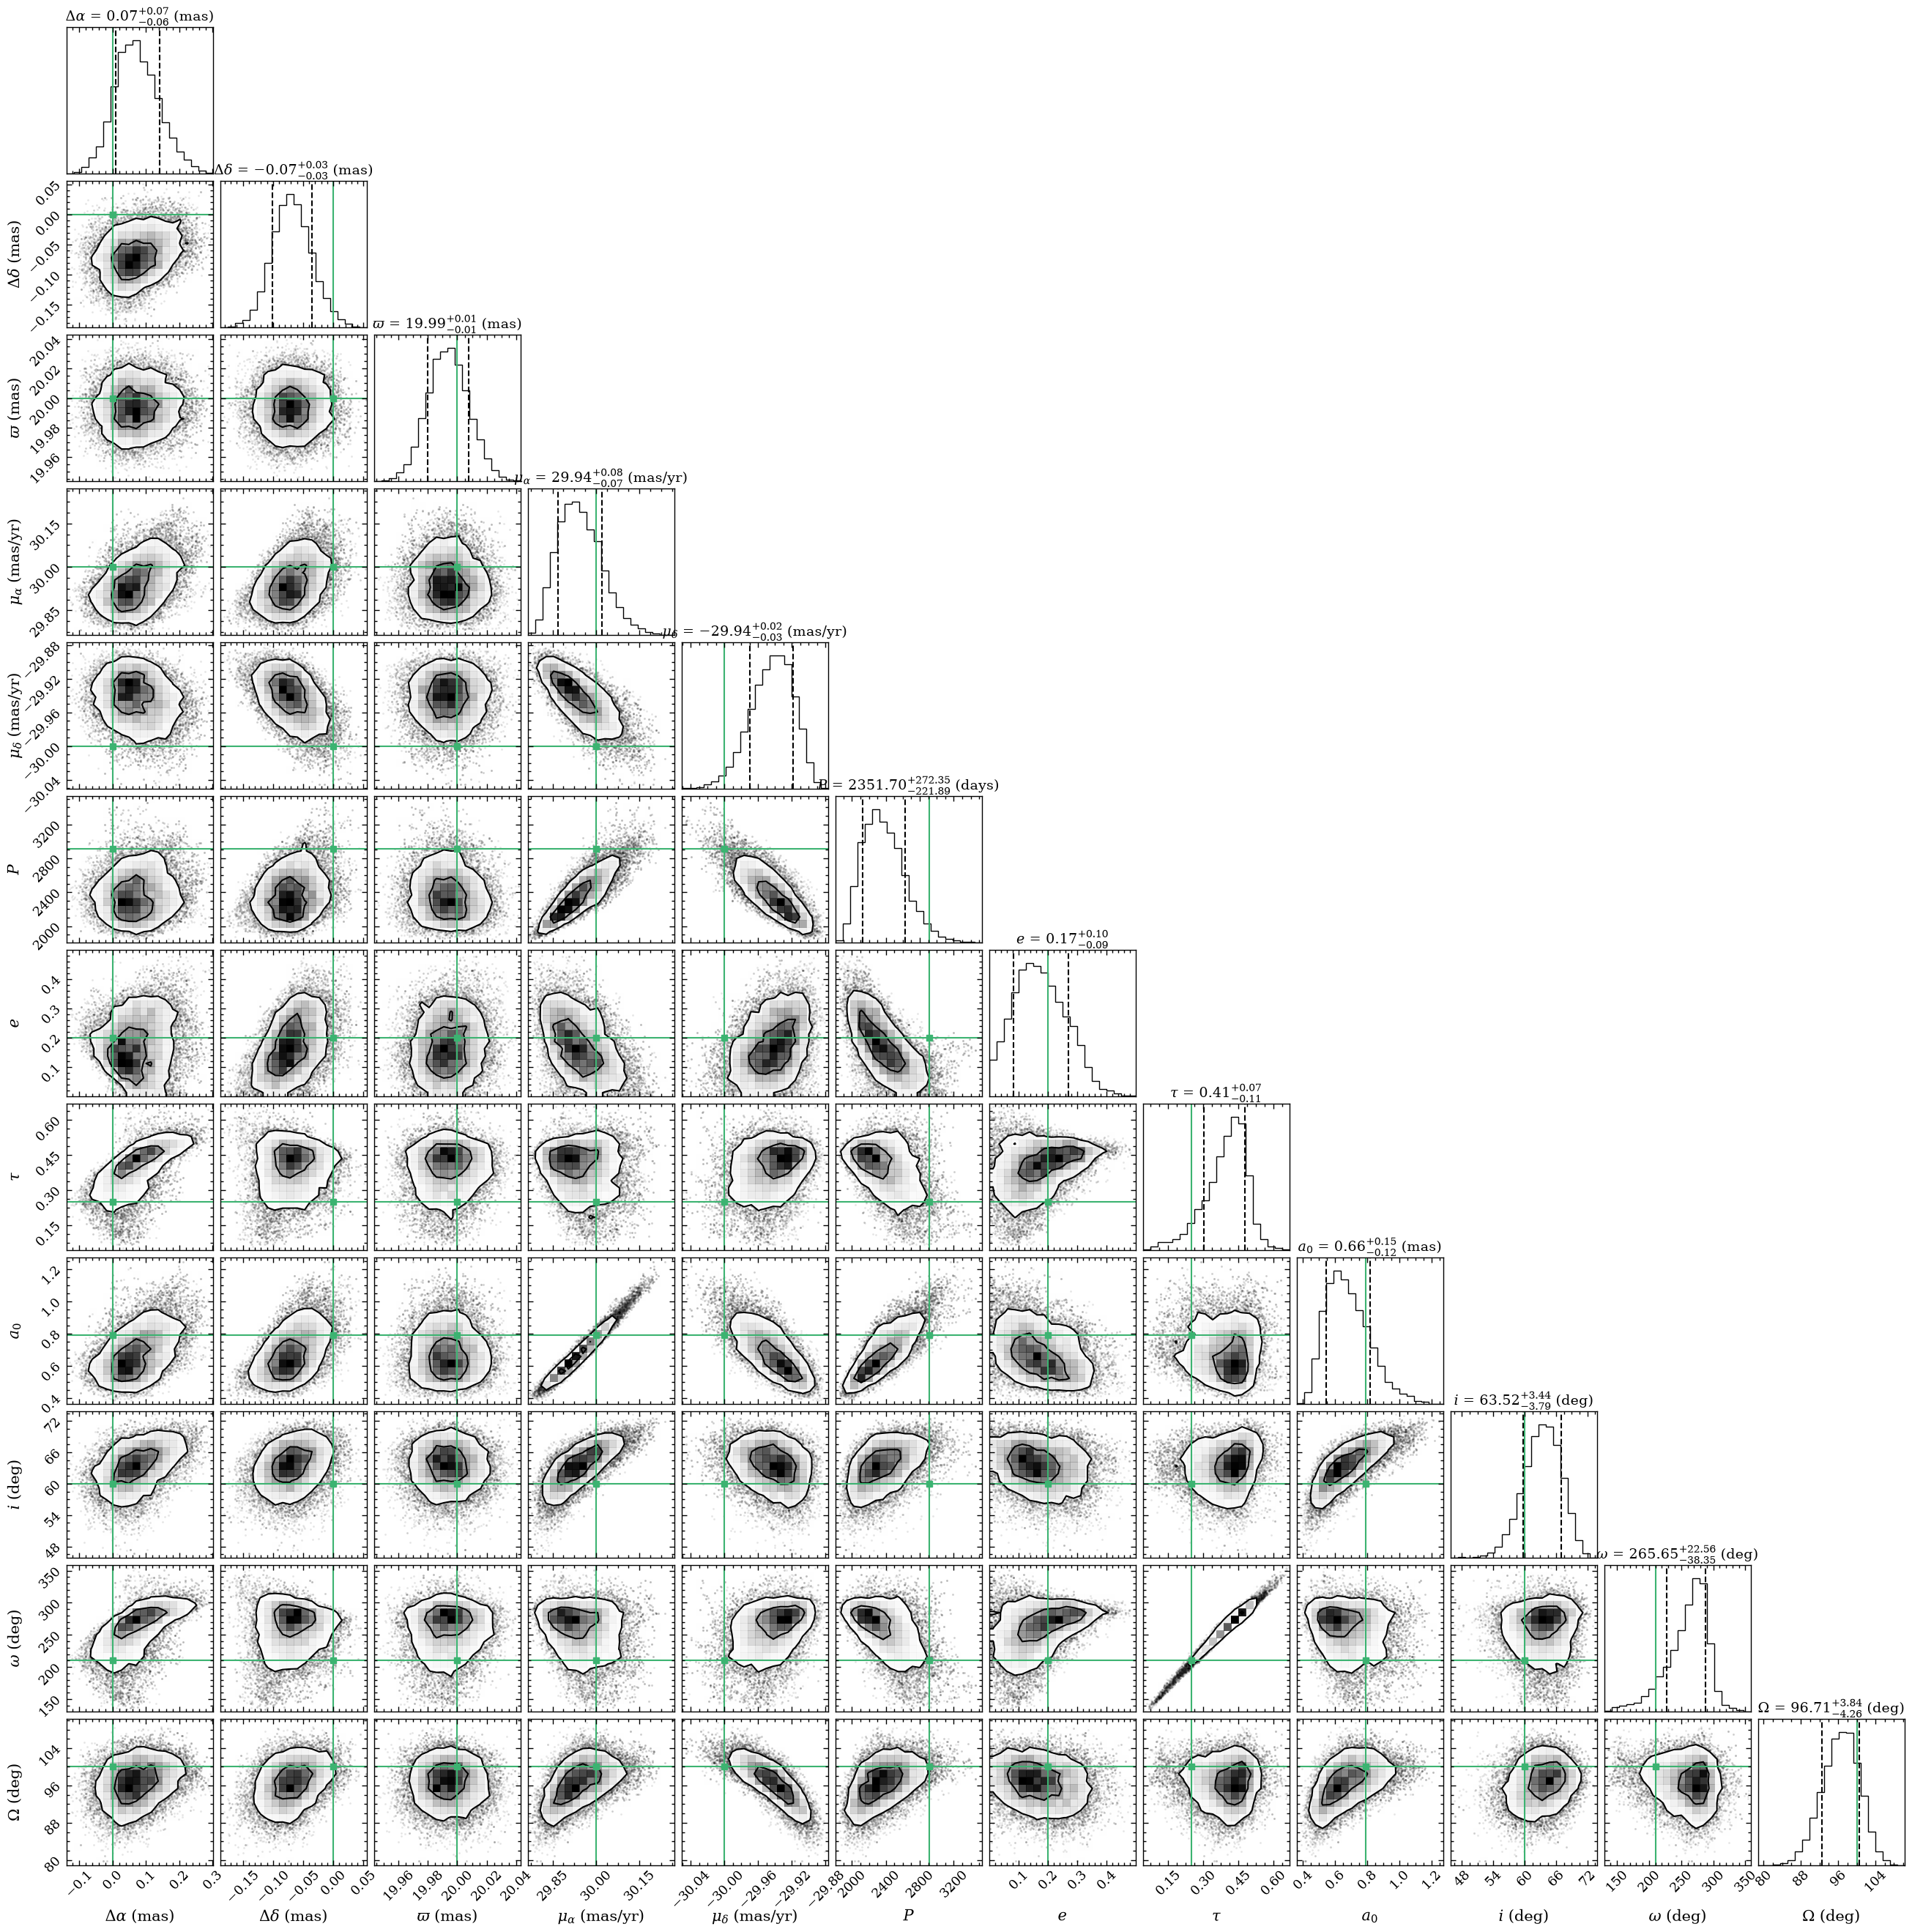

In [10]:
fig = results.plot_posterior(truths=model_param, outlier_fraction=None, plot_file='plot.png')


--------------
Plot residuals
--------------

Number of samples: 100

Output file: plot.png


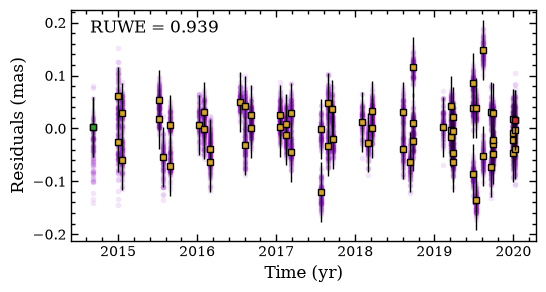

In [11]:
fig = results.plot_residuals(n_samples=100, seed=1, plot_file='plot.png')


----------
Plot orbit
----------


Output file: plot.png


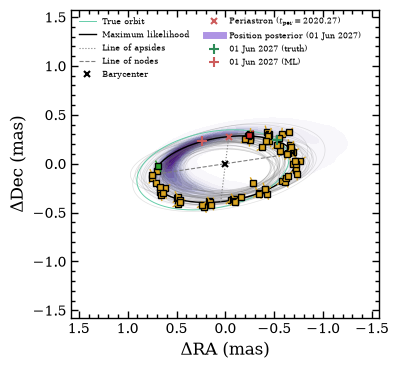

In [12]:
fig = results.plot_orbit(n_samples=50, truths=model_param, marker_time="2027-06-01", plot_file='plot.png')